# 04 - RFM Customer Segmentation

El objetivo de este notebook es segmentar la base de clientes utilizando el
modelo RFM (Recency, Frequency, Monetary), una metodología basada en el
comportamiento de compra.

La segmentación permitirá identificar grupos de clientes según tres dimensiones:

- **Recency (R):** tiempo transcurrido desde la última compra.
- **Frequency (F):** frecuencia de compra del cliente.
- **Monetary (M):** valor económico generado por el cliente.

A partir de estas dimensiones se construirán puntuaciones RFM y posteriormente
segmentos de clientes interpretables desde una perspectiva de marketing.

## Estructura

1. Carga de datos preparados
2. Selección de variables RFM
3. Análisis de las variables RFM
4. Construcción de scores RFM
5. Construcción del código RFM
6. Relación entre Frequency y Monetary
7. Construcción de segmentos RFM
8. Perfil de los segmentos
9. Conclusiones

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

## 1 Carga de datos preparados

Se utiliza el dataset generado durante la etapa de Data Preparation, que contiene
los datos originales considerados relevantes y las variables derivadas creadas
para representar de forma más directa el comportamiento de los clientes.

In [2]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/processed/customer_segmentation_prepared.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Dt_Customer"]
)

df.shape

(2240, 33)

In [3]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response',
 'Age',
 'CustomerTenure',
 'Children',
 'TotalSpend',
 'TotalPurchases',
 'CampaignAcceptances']

## 2 Selección de variables RFM

La segmentación RFM se construye a partir de tres dimensiones del comportamiento del cliente:

- **Recency (R):** tiempo transcurrido desde la última compra.
- **Frequency (F):** frecuencia de compra del cliente.
- **Monetary (M):** valor económico generado por el cliente.

El dataset ya proporciona `Recency`. Para representar Frequency y Monetary se utilizan respectivamente `TotalPurchases` y `TotalSpend`, variables creadas durante la etapa de Data Preparation.

Dado que el dataset contiene información agregada por cliente y no un histórico transaccional completo, Frequency y Monetary deben interpretarse como medidas agregadas disponibles para el periodo representado en los datos.

In [4]:
rfm_cols = [
    "Recency",
    "TotalPurchases",
    "TotalSpend"
]

df[rfm_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.0,99.0
TotalPurchases,2240.0,12.537054,7.205741,0.0,6.00,12.0,18.0,32.0
TotalSpend,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.5,2525.0


## 3 Análisis de las variables RFM

Antes de asignar puntuaciones RFM, se analizan las distribuciones de las tres variables para conocer su dispersión, asimetría y posibles valores extremos, y determinar una estrategia de scoring adecuada.

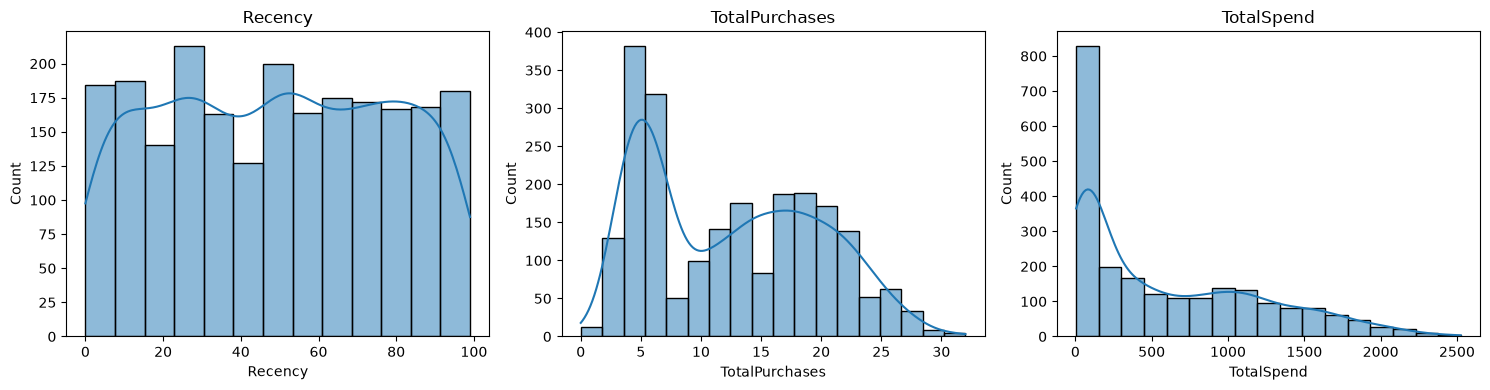

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, rfm_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [6]:
df[rfm_cols].skew()

Recency          -0.001987
TotalPurchases    0.297114
TotalSpend        0.860841
dtype: float64

`Recency` presenta una distribución prácticamente simétrica, mientras que `TotalPurchases` muestra una ligera asimetría positiva.

`TotalSpend` presenta una asimetría positiva más marcada, indicando que una parte reducida de los clientes concentra niveles de gasto considerablemente superiores al resto.

Estas diferencias de distribución refuerzan el uso de un sistema de puntuación basado en la posición relativa de cada cliente, en lugar de establecer umbrales absolutos comunes para las tres variables.

## 4 Construcción de scores RFM

Para transformar las tres dimensiones RFM en puntuaciones comparables se utilizan cuatro niveles basados en cuantiles.

Cada cliente recibe una puntuación entre 1 y 4:

- **Recency:** una menor recencia recibe una puntuación mayor, ya que representa
  una compra más reciente.
- **Frequency:** un mayor número de compras recibe una puntuación mayor.
- **Monetary:** un mayor gasto acumulado recibe una puntuación mayor.

De esta forma, una puntuación elevada representa un comportamiento más favorable en cada una de las tres dimensiones.

In [7]:
df[rfm_cols].nunique()

Recency            100
TotalPurchases      33
TotalSpend        1054
dtype: int64

In [8]:
df["TotalPurchases"].value_counts().sort_index()

TotalPurchases
0       6
1       6
2       2
3     128
4     202
5     180
6     191
7     128
8      51
9      45
10     54
11     77
12     64
13     75
14    100
15     84
16     98
17     89
18    104
19     85
20     85
21     86
22     75
23     64
24     52
25     39
26     24
27     23
28     10
29      6
30      2
31      2
32      3
Name: count, dtype: int64

`Recency` y `TotalSpend` presentan una cardinalidad suficiente para construir los scores mediante cuantiles.

`TotalPurchases` es una variable discreta con 33 valores diferentes y presenta un número considerable de empates. Por este motivo, se debe comprobar si los cuartiles pueden construirse directamente sin dividir clientes que presentan exactamente la misma frecuencia de compra.

In [9]:
df[rfm_cols].quantile([0.25, 0.50, 0.75])

,Recency,TotalPurchases,TotalSpend
0.25,24.0,6.0,68.75
0.50,49.0,12.0,396.00
0.75,74.0,18.0,1045.50


### 4.1 Asignación de puntuaciones RFM

A partir de los cuartiles observados se asigna a cada cliente una puntuación
entre 1 y 4 para cada dimensión RFM.

En `Recency` la puntuación se asigna de forma inversa: los clientes con compras
más recientes reciben una puntuación mayor.

En `Frequency` y `Monetary` ocurre lo contrario: un mayor número de compras o
un mayor gasto reciben una puntuación superior.

Los límites se mantienen explícitos para garantizar que clientes con el mismo
valor reciban siempre la misma puntuación, aunque esto pueda generar grupos de
tamaño ligeramente diferente.

In [10]:
rfm_quantiles = df[rfm_cols].quantile([0.25, 0.50, 0.75])

In [11]:
r_q1, r_q2, r_q3 = rfm_quantiles["Recency"]
f_q1, f_q2, f_q3 = rfm_quantiles["TotalPurchases"]
m_q1, m_q2, m_q3 = rfm_quantiles["TotalSpend"]

In [12]:
df["R_Score"] = pd.cut(
    df["Recency"],
    bins=[-float("inf"), r_q1, r_q2, r_q3, float("inf")],
    labels=[4, 3, 2, 1]
).astype(int)

df["F_Score"] = pd.cut(
    df["TotalPurchases"],
    bins=[-float("inf"), f_q1, f_q2, f_q3, float("inf")],
    labels=[1, 2, 3, 4]
).astype(int)

df["M_Score"] = pd.cut(
    df["TotalSpend"],
    bins=[-float("inf"), m_q1, m_q2, m_q3, float("inf")],
    labels=[1, 2, 3, 4]
).astype(int)

In [13]:
df[["Recency", "TotalPurchases", "TotalSpend",
    "R_Score", "F_Score", "M_Score"]].head(10)

,Recency,TotalPurchases,TotalSpend,R_Score,F_Score,M_Score
0,58,22,1617,2,4,4
1,38,4,27,3,1,1
2,26,20,776,3,4,3
3,26,6,53,3,1,1
4,94,14,422,1,3,3
5,16,20,716,4,4,3
6,34,17,590,3,3,3
7,32,8,169,3,2,2
8,19,5,46,4,1,1
9,68,1,49,2,1,1


In [14]:
score_cols = ["R_Score", "F_Score", "M_Score"]

for col in score_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


R_Score
R_Score
1    551
2    567
3    555
4    567
Name: count, dtype: int64

F_Score
F_Score
1    715
2    419
3    550
4    556
Name: count, dtype: int64

M_Score
M_Score
1    560
2    561
3    559
4    560
Name: count, dtype: int64


Las puntuaciones de `Recency` y `Monetary` presentan una distribución
prácticamente equilibrada entre los cuatro niveles.

En `Frequency` se observa una mayor concentración en el nivel 1. Esta diferencia
se debe al carácter discreto de `TotalPurchases` y a la presencia de numerosos
clientes con los mismos valores de frecuencia.

Se mantiene esta distribución para garantizar que clientes con el mismo número
de compras reciban la misma puntuación, priorizando la coherencia del criterio
de segmentación frente a la obtención de grupos exactamente iguales.

## 5 Construcción del código RFM

Las puntuaciones individuales se combinan para obtener un código RFM que representa simultáneamente la recencia, frecuencia y valor monetario de cada cliente.

El código conserva las tres dimensiones por separado, evitando perder información sobre la composición de la puntuación. Por ejemplo, clientes con la misma suma total pueden presentar comportamientos muy diferentes en Recency, Frequency y Monetary.

In [15]:
df["RFM_Code"] = (
    df["R_Score"].astype(str)
    + df["F_Score"].astype(str)
    + df["M_Score"].astype(str)
)

df[
    [
        "Recency",
        "TotalPurchases",
        "TotalSpend",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Code"
    ]
].head(10)

,Recency,TotalPurchases,TotalSpend,R_Score,F_Score,M_Score,RFM_Code
0,58,22,1617,2,4,4,244
1,38,4,27,3,1,1,311
2,26,20,776,3,4,3,343
3,26,6,53,3,1,1,311
4,94,14,422,1,3,3,133
5,16,20,716,4,4,3,443
6,34,17,590,3,3,3,333
7,32,8,169,3,2,2,322
8,19,5,46,4,1,1,411
9,68,1,49,2,1,1,211


In [16]:
df["RFM_Score"] = (
    df["R_Score"]
    + df["F_Score"]
    + df["M_Score"]
)

df["RFM_Score"].value_counts().sort_index()

RFM_Score
3     143
4     163
5     292
6     269
7     228
8     305
9     302
10    257
11    207
12     74
Name: count, dtype: int64

In [17]:
df["RFM_Code"].nunique()

46

In [18]:
df["RFM_Code"].value_counts().head(15)

RFM_Code
311    151
111    143
411    133
211    109
233    100
144     93
422     91
322     90
122     87
222     86
344     85
244     82
333     77
444     74
433     71
Name: count, dtype: int64

La combinación de las tres puntuaciones genera 46 códigos RFM diferentes de las 64 combinaciones teóricamente posibles.

Aunque también se calcula `RFM_Score` como suma de las tres dimensiones, esta medida no se utilizará por sí sola para definir los segmentos. Clientes con la misma puntuación total pueden presentar comportamientos muy diferentes en recencia, frecuencia y valor monetario.

Por este motivo, la construcción de segmentos conservará la información individual de R, F y M, agrupando posteriormente patrones de comportamiento similares en categorías interpretables desde una perspectiva de marketing.

## 6 Relación entre Frequency y Monetary

Frequency y Monetary representan dos dimensiones relacionadas con el valor histórico del cliente: el número de compras realizadas y el gasto acumulado.

Antes de definir los segmentos RFM, se analiza la relación entre ambas variables para determinar hasta qué punto aportan información complementaria.

In [19]:
df[["TotalPurchases", "TotalSpend"]].corr(method="spearman")

,TotalPurchases,TotalSpend
TotalPurchases,1.000000,0.908302
TotalSpend,0.908302,1.000000


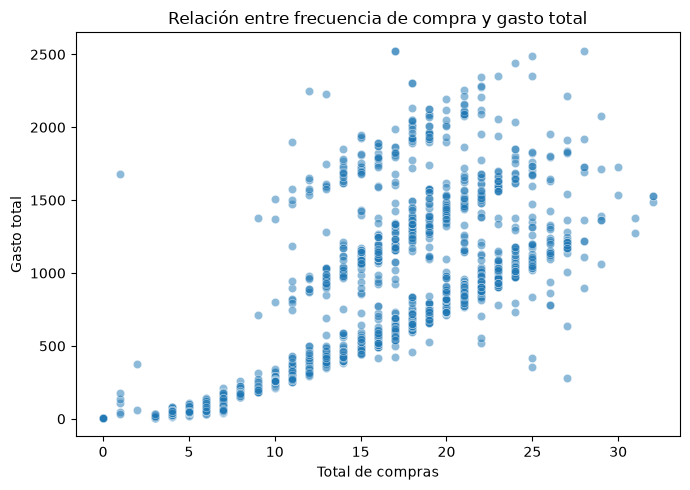

In [20]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="TotalPurchases",
    y="TotalSpend",
    alpha=0.5
)

plt.title("Relación entre frecuencia de compra y gasto total")
plt.xlabel("Total de compras")
plt.ylabel("Gasto total")

plt.tight_layout()
plt.show()

Se observa una asociación positiva muy fuerte entre `TotalPurchases` y `TotalSpend`, con un coeficiente de Spearman de 0,91.

En términos generales, los clientes que realizan un mayor número de compras también tienden a acumular un mayor nivel de gasto, aunque existe cierta variabilidad entre clientes con frecuencias de compra similares.

Por tanto, Frequency y Monetary aportan información estrechamente relacionada sobre el valor histórico del cliente. Ambas dimensiones se mantienen en RFM, pero esta relación se tendrá en cuenta al construir los segmentos para evitar una clasificación innecesariamente fragmentada.

## 7 Construcción de segmentos RFM

Los 46 códigos RFM observados generan una segmentación demasiado granular para su utilización directa en una estrategia de marketing.

Dada la fuerte relación observada entre Frequency y Monetary, se construye una medida auxiliar `FM_Score` como promedio de ambas puntuaciones. Esta medida resume el valor histórico del cliente manteniendo `R_Score` como dimensión independiente de actividad reciente.

A partir de la combinación entre recencia y valor histórico se definirán grupos de clientes con patrones de comportamiento diferenciados.

### 7.1 Construcción de FM Score

In [21]:
df["FM_Score"] = (
    df["F_Score"] + df["M_Score"]
) / 2

df["FM_Score"].value_counts().sort_index()

FM_Score
1.0    536
1.5    202
2.0    354
2.5     55
3.0    328
3.5    431
4.0    334
Name: count, dtype: int64

In [22]:
rfm_matrix = pd.crosstab(
    df["R_Score"],
    df["FM_Score"]
)

rfm_matrix

FM_Score,1.0,1.5,2.0,2.5,3.0,3.5,4.0
R_Score,,,,,,,
1,143,54,87,13,67,94,93
2,109,54,86,14,106,116,82
3,151,37,90,14,79,99,85
4,133,57,91,14,76,122,74


### 7.2 Definición de segmentos

A partir de `R_Score` y `FM_Score` se construyen seis segmentos que combinan la actividad reciente del cliente con su valor histórico.

La recencia se divide en dos niveles: clientes recientes (`R_Score >= 3`) y clientes menos recientes (`R_Score <= 2`). El valor histórico se divide en tres niveles: bajo (`FM_Score < 2`), medio (`2 <= FM_Score < 3`) y alto (`FM_Score >= 3`).

La combinación de ambos criterios genera seis segmentos mutuamente excluyentes y permite reducir la granularidad de los códigos RFM a grupos más fácilmente interpretables desde una perspectiva de marketing.

In [23]:
def assign_rfm_segment(row):
    r = row["R_Score"]
    fm = row["FM_Score"]

    if r >= 3 and fm >= 3:
        return "Champions"
    elif r >= 3 and fm >= 2:
        return "Loyal Customers"
    elif r >= 3:
        return "Potential Loyalists"
    elif fm >= 3:
        return "At Risk"
    elif fm >= 2:
        return "Need Attention"
    else:
        return "Hibernating"


df["RFM_Segment"] = df.apply(assign_rfm_segment, axis=1)

### 7.3 Distribución de los segmentos

In [24]:
segment_counts = (
    df["RFM_Segment"]
    .value_counts()
    .to_frame("Customers")
)

segment_counts["Percentage"] = (
    segment_counts["Customers"] / len(df) * 100
).round(2)

segment_counts

,Customers,Percentage
RFM_Segment,,
At Risk,558,24.91
Champions,535,23.88
Potential Loyalists,378,16.88
Hibernating,360,16.07
Loyal Customers,209,9.33
Need Attention,200,8.93


In [25]:
segment_counts["Customers"].sum(), len(df)

(np.int64(2240), 2240)

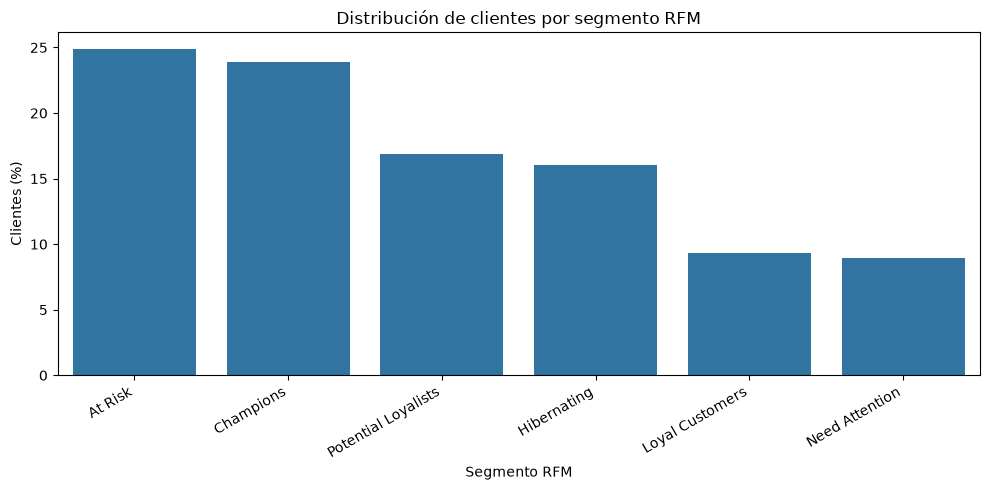

In [31]:
segment_plot = segment_counts.reset_index()
segment_plot.columns = ["RFM_Segment", "Customers", "Percentage"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_plot,
    x="RFM_Segment",
    y="Percentage"
)

plt.title("Distribución de clientes por segmento RFM")
plt.xlabel("Segmento RFM")
plt.ylabel("Clientes (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    "../reports/figures/rfm_segment_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 8 Perfil de los segmentos RFM

Una vez asignados los clientes a los seis segmentos, se analiza su comportamiento medio para comprobar que las reglas utilizadas generan grupos coherentes con la interpretación propuesta.

Para ello se comparan las principales variables utilizadas en la segmentación: recencia, número total de compras y gasto total.

In [26]:
rfm_profile = (
    df.groupby("RFM_Segment")
    .agg(
        Customers=("ID", "count"),
        Recency=("Recency", "mean"),
        TotalPurchases=("TotalPurchases", "mean"),
        TotalSpend=("TotalSpend", "mean")
    )
)

rfm_profile["Percentage"] = (
    rfm_profile["Customers"] / len(df) * 100
)

rfm_profile = rfm_profile[
    ["Customers", "Percentage", "Recency", "TotalPurchases", "TotalSpend"]
].round(2)

rfm_profile.sort_values("TotalSpend", ascending=False)

,Customers,Percentage,Recency,TotalPurchases,TotalSpend
RFM_Segment,,,,,
At Risk,558,24.91,73.62,18.87,1116.58
Champions,535,23.88,23.75,19.14,1101.17
Need Attention,200,8.93,75.26,9.54,267.80
Loyal Customers,209,9.33,24.01,9.52,253.42
Hibernating,360,16.07,74.49,4.69,53.88
Potential Loyalists,378,16.88,24.70,4.56,49.98


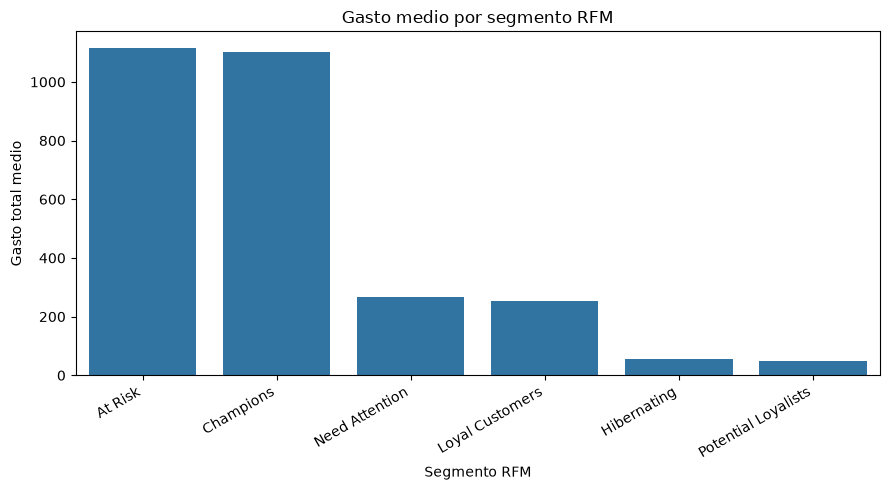

In [27]:
segment_order = (
    rfm_profile
    .sort_values("TotalSpend", ascending=False)
    .index
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="RFM_Segment",
    y="TotalSpend",
    order=segment_order,
    errorbar=None
)

plt.title("Gasto medio por segmento RFM")
plt.xlabel("Segmento RFM")
plt.ylabel("Gasto total medio")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [28]:
rfm_profile.sort_values("TotalSpend", ascending=False)

,Customers,Percentage,Recency,TotalPurchases,TotalSpend
RFM_Segment,,,,,
At Risk,558,24.91,73.62,18.87,1116.58
Champions,535,23.88,23.75,19.14,1101.17
Need Attention,200,8.93,75.26,9.54,267.80
Loyal Customers,209,9.33,24.01,9.52,253.42
Hibernating,360,16.07,74.49,4.69,53.88
Potential Loyalists,378,16.88,24.70,4.56,49.98


Los segmentos obtenidos presentan perfiles claramente diferenciados y coherentes con las reglas utilizadas en su construcción.

- **Champions (23,88 %):** clientes recientes y de alto valor. Presentan el
  mayor número medio de compras (19,14) y un gasto medio elevado (1.101,17),
  junto con una recencia reducida (23,75 días).

- **At Risk (24,91 %):** clientes de elevado valor histórico, con niveles de
  compra y gasto similares a los Champions, pero con una recencia
  considerablemente mayor (73,62 días). Constituyen un grupo especialmente
  relevante para estrategias de reactivación.

- **Loyal Customers (9,33 %):** clientes recientes con un nivel intermedio de
  frecuencia y gasto. Mantienen actividad reciente, aunque su valor histórico
  es inferior al de los Champions.

- **Need Attention (8,93 %):** presentan un valor histórico intermedio similar
  al de Loyal Customers, pero una recencia notablemente superior. Pueden ser
  candidatos a acciones destinadas a recuperar su actividad.

- **Potential Loyalists (16,88 %):** clientes recientes pero todavía con una
  frecuencia y gasto reducidos. Representan una oportunidad para incrementar
  su nivel de relación y desarrollar su valor futuro.

- **Hibernating (16,07 %):** clientes con baja frecuencia, bajo gasto y una
  recencia elevada. Constituyen el grupo de menor actividad y valor dentro de
  la segmentación.

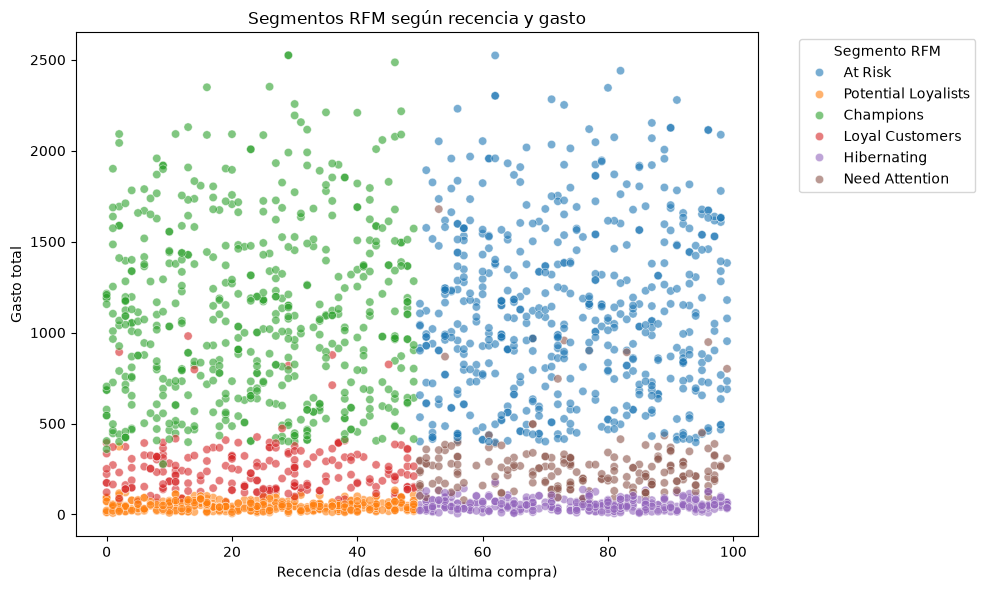

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Recency",
    y="TotalSpend",
    hue="RFM_Segment",
    alpha=0.6
)

plt.title("Segmentos RFM según recencia y gasto")
plt.xlabel("Recencia (días desde la última compra)")
plt.ylabel("Gasto total")
plt.legend(
    title="Segmento RFM",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/rfm_recency_spend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 9 Conclusiones

La segmentación RFM permite transformar los 46 códigos observados en seis grupos de clientes con perfiles de comportamiento diferenciados e interpretables desde una perspectiva de marketing.

Los resultados muestran que la recencia aporta una dimensión especialmente relevante. Clientes con niveles de frecuencia y gasto similares pueden presentar situaciones comerciales muy diferentes dependiendo del tiempo transcurrido desde su última compra.

Esta diferencia se observa especialmente entre `Champions` y `At Risk`, así como entre `Potential Loyalists` y `Hibernating`.

La segmentación obtenida proporciona una clasificación basada exclusivamente en el comportamiento de compra y constituye una primera aproximación interpretable a la estructura de la base de clientes.

En un análisis posterior se aplicará K-Means como enfoque alternativo de segmentación multivariable, permitiendo comparar una metodología basada en reglas de negocio con un método de clustering no supervisado.